Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2 — Import libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cell 3 — Define paths

In [6]:
BASE_PATH = "/content/drive/MyDrive/fitness-journey-analyzer/data"
PROCESSED_PATH = os.path.join(BASE_PATH, "processed")

pose_file = os.path.join(PROCESSED_PATH, "pose_scores_sample.csv")
nlp_file = os.path.join(PROCESSED_PATH, "nlp_workout_log_results.csv")
forecast_file = os.path.join(PROCESSED_PATH, "fitness_forecast.csv")

print("Pose file exists:", os.path.exists(pose_file))
print("NLP file exists:", os.path.exists(nlp_file))
print("Forecast file exists:", os.path.exists(forecast_file))

Pose file exists: True
NLP file exists: True
Forecast file exists: True


In [5]:
import os

PROCESSED_PATH = "/content/drive/MyDrive/fitness-journey-analyzer/data/processed"

print(os.listdir(PROCESSED_PATH))

['pose_scores_sample.csv', 'nlp_workout_log_results.csv', 'fitness_forecast.csv']


Cell 4 — Load all result files

In [7]:
df_pose = pd.read_csv(pose_file)
df_nlp = pd.read_csv(nlp_file)
df_forecast = pd.read_csv(forecast_file)

print("Pose shape:", df_pose.shape)
print("NLP shape:", df_nlp.shape)
print("Forecast shape:", df_forecast.shape)

Pose shape: (10, 4)
NLP shape: (8, 6)
Forecast shape: (395, 16)


Cell 5 — Preview files

In [8]:
display(df_pose.head())
display(df_nlp.head())
display(df_forecast.head())

,image_file,exercise,knee_angle,posture_score
0,barbell biceps curl_3800031.jpg,barbell biceps curl,75.025930,0.833622
1,barbell biceps curl_2200011.jpg,barbell biceps curl,16.251902,0.180577
2,barbell biceps curl_300001.jpg,barbell biceps curl,175.563250,0.049297
3,barbell biceps curl_4500291.jpg,barbell biceps curl,179.635090,0.004055
4,barbell biceps curl_1200111.jpg,barbell biceps curl,179.444980,0.006167


,text,clean_text,sentiment_label,sentiment_score,effort_label,fatigue_label
0,felt strong today lifted 80kg bench press,felt strong today lifted 80kg bench press,positive,0.999512,high,low
1,too tired today skipped workout,too tired today skipped workout,negative,0.999053,low,high
2,great leg day squats felt powerful,great leg day squats felt powerful,positive,0.998333,high,low
3,low energy workout today,low energy workout today,negative,0.998666,low,medium
4,amazing push workout feeling confident,amazing push workout feeling confident,positive,0.999825,high,low


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-01-01,85.669923,57.178339,111.682436,85.669923,85.669923,0.001483,0.001483,0.001483,0.001483,0.001483,0.001483,0.0,0.0,0.0,85.671407
1,2023-01-02,85.683675,58.720399,113.269981,85.683675,85.683675,0.001016,0.001016,0.001016,0.001016,0.001016,0.001016,0.0,0.0,0.0,85.684691
2,2023-01-03,85.697427,58.388667,112.933853,85.697427,85.697427,0.000460,0.000460,0.000460,0.000460,0.000460,0.000460,0.0,0.0,0.0,85.697887
3,2023-01-04,85.711179,58.754859,113.804444,85.711179,85.711179,-0.000096,-0.000096,-0.000096,-0.000096,-0.000096,-0.000096,0.0,0.0,0.0,85.711083
4,2023-01-05,85.724931,58.051794,111.516915,85.724931,85.724931,-0.000652,-0.000652,-0.000652,-0.000652,-0.000652,-0.000652,0.0,0.0,0.0,85.724279


Cell 6 — Standardize pose data

In [9]:
# Add a date column if not already present
if "date" not in df_pose.columns:
    df_pose["date"] = pd.Timestamp.today().normalize()

# Standardize column names if needed
rename_map_pose = {}
if "exercise" not in df_pose.columns and "exercise_type" in df_pose.columns:
    rename_map_pose["exercise_type"] = "exercise"
if "posture_score" not in df_pose.columns:
    # keep as-is if already exists
    pass

df_pose = df_pose.rename(columns=rename_map_pose)

df_pose["date"] = pd.to_datetime(df_pose["date"]).dt.date
df_pose.head()

,image_file,exercise,knee_angle,posture_score,date
0,barbell biceps curl_3800031.jpg,barbell biceps curl,75.025930,0.833622,2026-03-10
1,barbell biceps curl_2200011.jpg,barbell biceps curl,16.251902,0.180577,2026-03-10
2,barbell biceps curl_300001.jpg,barbell biceps curl,175.563250,0.049297,2026-03-10
3,barbell biceps curl_4500291.jpg,barbell biceps curl,179.635090,0.004055,2026-03-10
4,barbell biceps curl_1200111.jpg,barbell biceps curl,179.444980,0.006167,2026-03-10


Cell 7 — Standardize NLP data

In [10]:
# Add a date column if not already present
if "date" not in df_nlp.columns:
    df_nlp["date"] = pd.Timestamp.today().normalize()

df_nlp["date"] = pd.to_datetime(df_nlp["date"]).dt.date

# Keep only useful columns if present
useful_nlp_cols = [col for col in [
    "date", "text", "sentiment_label", "sentiment_score",
    "effort_label", "fatigue_label"
] if col in df_nlp.columns]

df_nlp = df_nlp[useful_nlp_cols]
df_nlp.head()

,date,text,sentiment_label,sentiment_score,effort_label,fatigue_label
0,2026-03-10,felt strong today lifted 80kg bench press,positive,0.999512,high,low
1,2026-03-10,too tired today skipped workout,negative,0.999053,low,high
2,2026-03-10,great leg day squats felt powerful,positive,0.998333,high,low
3,2026-03-10,low energy workout today,negative,0.998666,low,medium
4,2026-03-10,amazing push workout feeling confident,positive,0.999825,high,low


Cell 8 — Standardize forecast data

In [11]:
df_forecast["ds"] = pd.to_datetime(df_forecast["ds"])
df_forecast = df_forecast.sort_values("ds")

forecast_cols = ["ds", "yhat", "yhat_lower", "yhat_upper"]
df_forecast = df_forecast[forecast_cols]

df_forecast.head()

,ds,yhat,yhat_lower,yhat_upper
0,2023-01-01,85.671407,57.178339,111.682436
1,2023-01-02,85.684691,58.720399,113.269981
2,2023-01-03,85.697887,58.388667,112.933853
3,2023-01-04,85.711083,58.754859,113.804444
4,2023-01-05,85.724279,58.051794,111.516915


Cell 9 — Extract only future forecast rows

In [12]:
today = pd.Timestamp.today().normalize()
df_future = df_forecast[df_forecast["ds"] >= today].copy()

print("Future forecast rows:", df_future.shape[0])
df_future.head()

Future forecast rows: 0


,ds,yhat,yhat_lower,yhat_upper


Cell 10 — Create a simple current-user summary

In [13]:
latest_pose = df_pose.iloc[-1] if len(df_pose) > 0 else None
latest_nlp = df_nlp.iloc[-1] if len(df_nlp) > 0 else None
latest_forecast = df_future.iloc[0] if len(df_future) > 0 else None

summary = {
    "date": pd.Timestamp.today().date(),
    "exercise": latest_pose["exercise"] if latest_pose is not None and "exercise" in latest_pose else "unknown",
    "posture_score": float(latest_pose["posture_score"]) if latest_pose is not None and "posture_score" in latest_pose else np.nan,
    "sentiment_label": latest_nlp["sentiment_label"] if latest_nlp is not None and "sentiment_label" in latest_nlp else "unknown",
    "sentiment_score": float(latest_nlp["sentiment_score"]) if latest_nlp is not None and "sentiment_score" in latest_nlp else np.nan,
    "effort_label": latest_nlp["effort_label"] if latest_nlp is not None and "effort_label" in latest_nlp else "unknown",
    "fatigue_label": latest_nlp["fatigue_label"] if latest_nlp is not None and "fatigue_label" in latest_nlp else "unknown",
    "forecast_date": latest_forecast["ds"].date() if latest_forecast is not None else None,
    "predicted_weight": float(latest_forecast["yhat"]) if latest_forecast is not None else np.nan,
    "predicted_weight_lower": float(latest_forecast["yhat_lower"]) if latest_forecast is not None else np.nan,
    "predicted_weight_upper": float(latest_forecast["yhat_upper"]) if latest_forecast is not None else np.nan,
}

df_summary = pd.DataFrame([summary])
df_summary

,date,exercise,posture_score,sentiment_label,sentiment_score,effort_label,fatigue_label,forecast_date,predicted_weight,predicted_weight_lower,predicted_weight_upper
0,2026-03-10,barbell biceps curl,0.732027,positive,0.99974,high,medium,None,NaN,NaN,NaN


Cell 11 — Generate a natural-language insight

In [14]:
def build_insight(row):
    exercise = row["exercise"]
    posture = row["posture_score"]
    sentiment = row["sentiment_label"]
    effort = row["effort_label"]
    fatigue = row["fatigue_label"]
    pred_wt = row["predicted_weight"]
    fdate = row["forecast_date"]

    posture_text = "good" if pd.notna(posture) and posture >= 0.75 else "needs improvement"

    return (
        f"Latest workout detected: {exercise}. "
        f"Posture quality is {posture_text} (score={posture:.2f}). "
        f"Workout mood is {sentiment}, effort is {effort}, and fatigue is {fatigue}. "
        f"Predicted body weight by {fdate} is {pred_wt:.2f} kg."
    )

df_summary["insight_text"] = df_summary.apply(build_insight, axis=1)
df_summary[["insight_text"]]

,insight_text
0,Latest workout detected: barbell biceps curl. ...


Cell 12 — Build a compact dashboard table

In [15]:
dashboard_df = df_summary[[
    "date", "exercise", "posture_score",
    "sentiment_label", "effort_label", "fatigue_label",
    "forecast_date", "predicted_weight",
    "predicted_weight_lower", "predicted_weight_upper"
]]

dashboard_df

,date,exercise,posture_score,sentiment_label,effort_label,fatigue_label,forecast_date,predicted_weight,predicted_weight_lower,predicted_weight_upper
0,2026-03-10,barbell biceps curl,0.732027,positive,high,medium,None,NaN,NaN,NaN


Cell 13 — Plot forecast chart

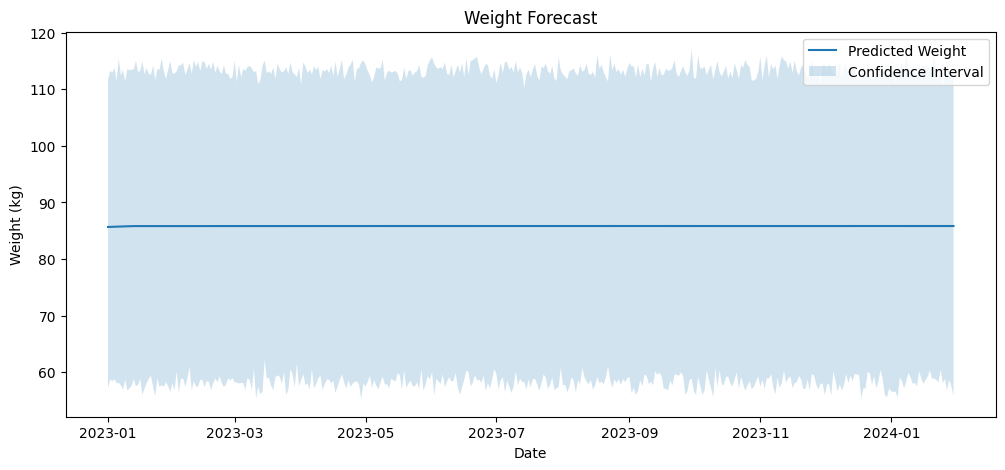

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(df_forecast["ds"], df_forecast["yhat"], label="Predicted Weight")
plt.fill_between(
    df_forecast["ds"],
    df_forecast["yhat_lower"],
    df_forecast["yhat_upper"],
    alpha=0.2,
    label="Confidence Interval"
)
plt.title("Weight Forecast")
plt.xlabel("Date")
plt.ylabel("Weight (kg)")
plt.legend()
plt.show()

Cell 14 — Plot posture score distribution

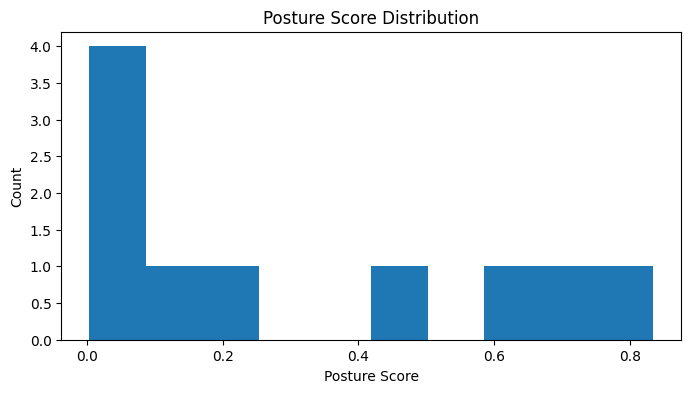

In [17]:
if "posture_score" in df_pose.columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df_pose["posture_score"], bins=10)
    plt.title("Posture Score Distribution")
    plt.xlabel("Posture Score")
    plt.ylabel("Count")
    plt.show()

Cell 15 — Plot NLP category distributions

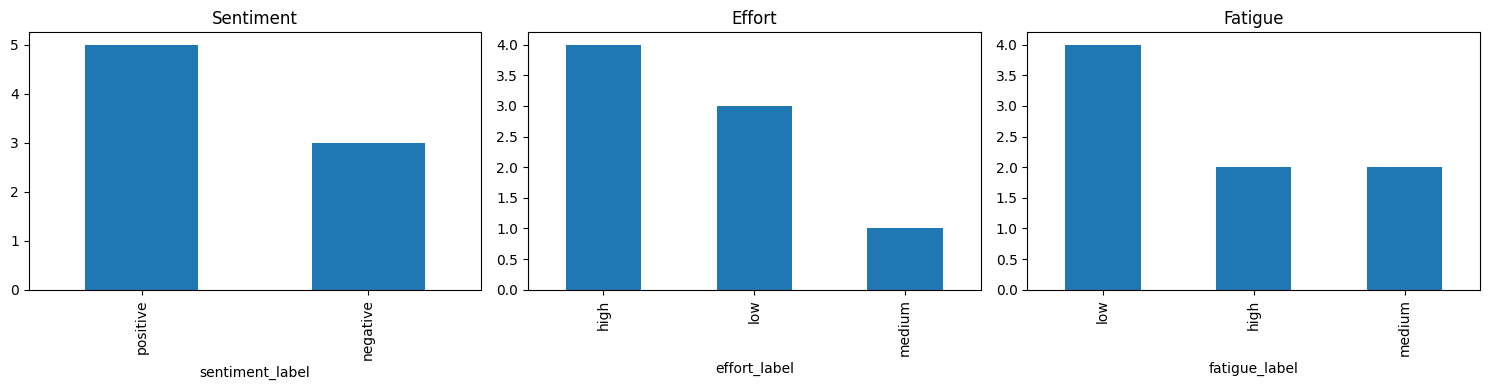

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if "sentiment_label" in df_nlp.columns:
    df_nlp["sentiment_label"].value_counts().plot(kind="bar", ax=axes[0], title="Sentiment")

if "effort_label" in df_nlp.columns:
    df_nlp["effort_label"].value_counts().plot(kind="bar", ax=axes[1], title="Effort")

if "fatigue_label" in df_nlp.columns:
    df_nlp["fatigue_label"].value_counts().plot(kind="bar", ax=axes[2], title="Fatigue")

plt.tight_layout()
plt.show()

Cell 16 — Save final integrated outputs

In [19]:
final_summary_file = os.path.join(PROCESSED_PATH, "final_dashboard_summary.csv")
final_insight_file = os.path.join(PROCESSED_PATH, "final_insights.csv")

dashboard_df.to_csv(final_summary_file, index=False)
df_summary[["insight_text"]].to_csv(final_insight_file, index=False)

print("Saved summary to:", final_summary_file)
print("Saved insights to:", final_insight_file)

Saved summary to: /content/drive/MyDrive/fitness-journey-analyzer/data/processed/final_dashboard_summary.csv
Saved insights to: /content/drive/MyDrive/fitness-journey-analyzer/data/processed/final_insights.csv


Cell 17 — Optional: create a timeline table

In [20]:
# Make lightweight timeline versions
pose_timeline = df_pose.copy()
pose_timeline["source"] = "cv"

nlp_timeline = df_nlp.copy()
nlp_timeline["source"] = "nlp"

# Keep only common-ish columns for a combined view
pose_keep = [c for c in ["date", "source", "exercise", "posture_score"] if c in pose_timeline.columns]
nlp_keep = [c for c in ["date", "source", "sentiment_label", "effort_label", "fatigue_label"] if c in nlp_timeline.columns]

pose_timeline = pose_timeline[pose_keep]
nlp_timeline = nlp_timeline[nlp_keep]

timeline_df = pd.concat([pose_timeline, nlp_timeline], ignore_index=True, sort=False)
timeline_df = timeline_df.sort_values("date")

timeline_file = os.path.join(PROCESSED_PATH, "combined_timeline.csv")
timeline_df.to_csv(timeline_file, index=False)

print("Saved timeline to:", timeline_file)
timeline_df.head(10)

Saved timeline to: /content/drive/MyDrive/fitness-journey-analyzer/data/processed/combined_timeline.csv


,date,source,exercise,posture_score,sentiment_label,effort_label,fatigue_label
0,2026-03-10,cv,barbell biceps curl,0.833622,NaN,NaN,NaN
15,2026-03-10,nlp,NaN,NaN,negative,medium,high
14,2026-03-10,nlp,NaN,NaN,positive,high,low
13,2026-03-10,nlp,NaN,NaN,negative,low,medium
12,2026-03-10,nlp,NaN,NaN,positive,high,low
11,2026-03-10,nlp,NaN,NaN,negative,low,high
10,2026-03-10,nlp,NaN,NaN,positive,high,low
9,2026-03-10,cv,barbell biceps curl,0.732027,NaN,NaN,NaN
8,2026-03-10,cv,barbell biceps curl,0.150740,NaN,NaN,NaN
7,2026-03-10,cv,barbell biceps curl,0.013758,NaN,NaN,NaN
